# Bellabeat Marketing Analysis — Section 4: Analyze

**Author:** An Truong  
**Project:** Google Data Analytics Certificate Capstone  
**Tool:** Python (pandas, matplotlib, seaborn)  
**Dataset:** FitBit Fitness Tracker Data (CC0 Public Domain, via Kaggle/Mobius)  

---

## Overview

This notebook covers the **Analyze phase** of the Bellabeat case study. Data was cleaned and aggregated in Google BigQuery SQL (see `Bellabeat_Process_Cleaning.sql`) and exported as CSV files for analysis here.

**Business Task:** Analyze smart device usage data to identify how consumers use non-Bellabeat devices, and apply those insights to inform Bellabeat App marketing strategy.

**Three guiding questions:**
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

---

## Sections
- [4.1 Summary Statistics](#41-summary-statistics)
- [4.2 Key Trends](#42-key-trends)
  - [Peak Activity Hours](#peak-activity-hours)
  - [Activity vs. Sleep Correlation](#activity-vs-sleep-correlation)
  - [Weekday vs. Weekend Patterns](#weekday-vs-weekend-patterns)
- [4.3 User Segmentation](#43-user-segmentation)

---
## Setup: Import Libraries and Load Data

Six tables exported from BigQuery are loaded here:

| Variable | Source Table | Rows | Description |
|---|---|---|---|
| `daily_activity` | `flagged_dailyActivity` | 457 | Daily activity with non-wear day flag |
| `daily_sleep` | `agg_dailySleep` | 467 | Daily sleep totals derived from minute-level data |
| `wear_rate` | `agg_wearRate` | 35 | Per-user device wear rate |
| `hourly_steps` | `clean_hourlySteps` | 24,084 | Hourly step counts |
| `hourly_intensities` | `clean_hourlyIntensities` | 24,084 | Hourly average intensity |
| `daily_heartrate` | `agg_dailyHeartrate` | 143 | Daily heart rate aggregated from second-level data |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load exported BigQuery tables
daily_activity    = pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/flagged_dailyActivity.csv')
daily_sleep       = pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/agg_dailySleep.csv')
wear_rate         = pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/agg_wearRate.csv')
hourly_steps      = pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/clean_hourlySteps.csv')
hourly_intensities= pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/clean_hourlyIntensities.csv')
daily_heartrate   = pd.read_csv('/Users/nathan/Desktop/Bellabeat_CaseStudy/agg_dailyHeartrate.csv')

print('Shapes (rows, columns):')
for name, df in [('daily_activity', daily_activity), ('daily_sleep', daily_sleep),
                 ('wear_rate', wear_rate), ('hourly_steps', hourly_steps),
                 ('hourly_intensities', hourly_intensities), ('daily_heartrate', daily_heartrate)]:
    print(f'  {name}: {df.shape}')

Shapes (rows, columns):
  daily_activity: (457, 9)
  daily_sleep: (467, 5)
  wear_rate: (35, 5)
  hourly_steps: (24084, 3)
  hourly_intensities: (24084, 4)
  daily_heartrate: (143, 5)


---
## 4.1 Summary Statistics

Descriptive statistics across activity, sleep, and heart rate metrics.
Non-wear days (53 rows where `TotalSteps = 0` and `SedentaryMinutes = 1440`) are excluded from
activity analysis using boolean masking so they do not artificially drag down activity averages.

In [2]:
# Filter to real wear days only using boolean masking
# .copy() prevents SettingWithCopyWarning when adding columns later
active_days = daily_activity[daily_activity['is_non_wear_day'] == False].copy()

print(f'Total rows in daily_activity: {len(daily_activity)}')
print(f'Wear days retained: {len(active_days)}')
print(f'Non-wear days excluded: {len(daily_activity) - len(active_days)}')

Total rows in daily_activity: 457
Wear days retained: 404
Non-wear days excluded: 53


In [3]:
# Check for zero-step wear days that slipped through the non-wear filter
# (TotalSteps = 0 but SedentaryMinutes != 1440)
zero_step_wear_days = active_days[active_days['TotalSteps'] == 0].shape[0]
print(f'Zero-step wear days remaining after filter: {zero_step_wear_days}')
print('Note: These represent genuinely sedentary days or partial device wear, not confirmed non-wear.')

Zero-step wear days remaining after filter: 8
Note: These represent genuinely sedentary days or partial device wear, not confirmed non-wear.


In [4]:
# Summary statistics — Activity (404 wear days, 35 users)
active_days[['TotalSteps', 'Calories', 'VeryActiveMinutes',
             'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']].describe().round(1)

,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
count,404.0,404.0,404.0,404.0,404.0,404.0
mean,7405.4,2267.7,18.8,14.8,192.4,936.9
std,5157.6,811.8,30.1,38.2,112.2,314.8
min,0.0,50.0,0.0,0.0,0.0,32.0
25%,3155.8,1797.8,0.0,0.0,116.5,702.0
50%,6800.0,2167.0,2.0,6.0,198.5,929.0
75%,10555.2,2783.8,27.2,18.0,266.2,1185.0
max,28497.0,4562.0,202.0,660.0,720.0,1440.0


**Key activity findings:**
- Mean daily steps: **7,405** — below the widely cited 10,000-step benchmark, suggesting an engagement gap
- Mean sedentary minutes: **937** (~15.6 hours/day) — users wear the device through their entire day, not just during exercise
- Mean very active minutes: **18.8/day** — moderate activity level; most activity falls in the lightly active category

In [5]:
# Summary statistics — Sleep (467 days, 23 users)
daily_sleep[['TotalMinutesAsleep', 'TotalTimeInBed', 'TotalSleepRecords']].describe().round(1)

,TotalMinutesAsleep,TotalTimeInBed,TotalSleepRecords
count,467.0,467.0,467.0
mean,391.9,424.1,1.8
std,152.3,161.8,0.8
min,6.0,6.0,1.0
25%,329.0,365.0,1.0
50%,421.0,450.0,2.0
75%,491.5,520.0,2.0
max,791.0,903.0,6.0


**Key sleep findings:**
- Mean minutes asleep: **392 (~6.5 hours)** — within the 6–7 hour range for adults
- Mean time in bed: **424 minutes (~7.1 hours)**
- Average sleep gap: **~32 minutes** spent in bed but not asleep — opportunity for mindfulness/sleep coaching
- 59% of days have 2+ sleep sessions logged, reflecting naps or fragmented sleep

In [6]:
# Summary statistics — Heart Rate (143 days, 14 users)
daily_heartrate[['AverageHeartrate', 'MinHeartrate', 'MaxHeartrate']].describe().round(1)

,AverageHeartrate,MinHeartrate,MaxHeartrate
count,143.0,143.0,143.0
mean,79.8,53.8,137.8
std,10.3,6.6,21.8
min,56.8,36.0,80.0
25%,72.8,50.0,124.5
50%,79.2,53.0,134.0
75%,87.5,57.5,153.0
max,109.8,70.0,185.0


**Key heart rate findings:**
- Mean average BPM: **79.8** — within normal resting range (60–100 BPM)
- Mean max BPM: **137.8** — suggests moderate intensity exercise sessions
- Note: Only 14 of 35 users tracked heart rate, limiting generalizability

---
## 4.2 Key Trends

### Peak Activity Hours

Analyzing average step counts by hour of day to identify when users are most physically active.
The `ActivityHour` column is converted from string to datetime, then the hour is extracted
using the `.dt` accessor — a pandas tool for datetime operations.

In [7]:
# Convert ActivityHour from string to datetime, then extract hour
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_steps['Hour'] = hourly_steps['ActivityHour'].dt.hour

# Average steps per hour across all users
steps_by_hour = hourly_steps.groupby('Hour')['StepTotal'].mean()
print(steps_by_hour)

Hour
0      44.421156
1      20.484819
2      10.588639
3       7.312071
4       9.755403
5      26.113078
6     120.164370
7     267.120316
8     365.596439
9     430.258416
10    437.004995
11    452.745236
12    520.944779
13    457.882530
14    474.124498
15    390.469347
16    447.366834
17    453.663984
18    505.646526
19    528.878147
20    399.317861
21    261.009082
22    172.983838
23    102.901822
Name: StepTotal, dtype: float64


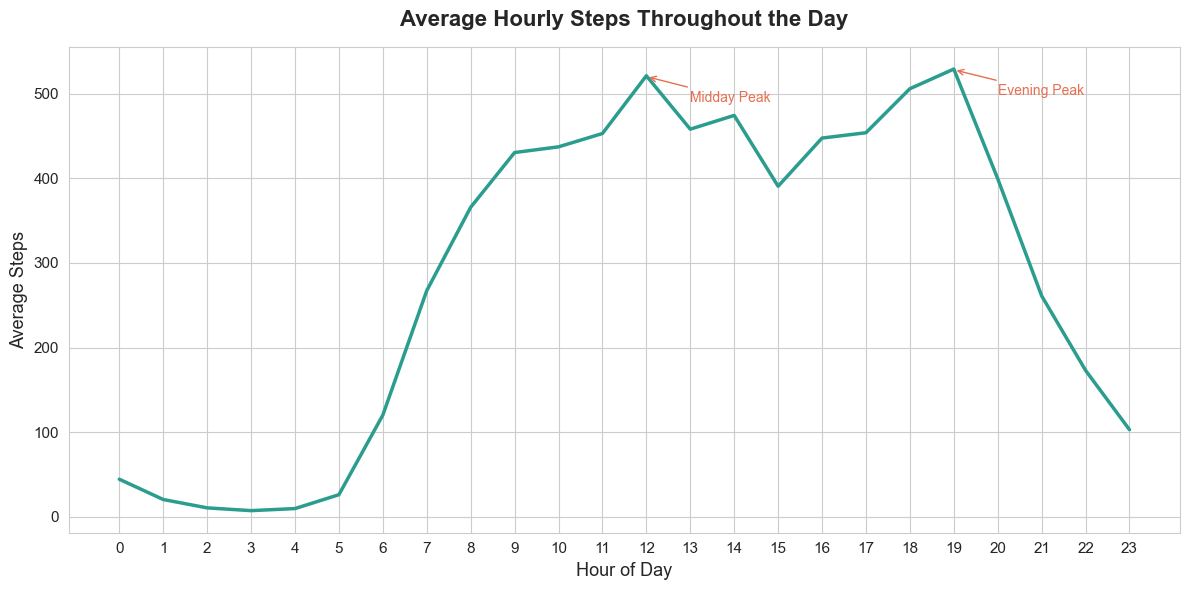

In [8]:
# Visualization: Average Hourly Steps Throughout the Day
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
sns.lineplot(x=steps_by_hour.index, y=steps_by_hour.values,
             color='#2A9D8F', linewidth=2.5)
plt.title('Average Hourly Steps Throughout the Day',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of Day', fontsize=13)
plt.ylabel('Average Steps', fontsize=13)
plt.xticks(range(0, 24), fontsize=11)
plt.yticks(fontsize=11)
plt.annotate('Midday Peak', xy=(12, 520), xytext=(13, 490),
             fontsize=10, color='#E76F51',
             arrowprops=dict(arrowstyle='->', color='#E76F51'))
plt.annotate('Evening Peak', xy=(19, 528), xytext=(20, 498),
             fontsize=10, color='#E76F51',
             arrowprops=dict(arrowstyle='->', color='#E76F51'))
plt.tight_layout()
plt.show()

**Finding:** Activity is concentrated between hours 8–20, with two clear peaks at **12pm (midday)** and **7pm (evening)**.
The pattern suggests a lunch-break activity window and a post-work activity window.

**Marketing implication:** Bellabeat App notifications and engagement prompts should be timed
to align with these natural activity windows rather than arbitrary times.

---
### Activity vs. Sleep Correlation

Testing whether daily activity levels correlate with sleep duration.
`active_days` and `daily_sleep` are merged on `Id` and date to create matched activity-sleep pairs.
Note: Only days where both activity and sleep were tracked are included (199 of 404 wear days).

In [9]:
# Merge activity and sleep data on Id + date
# left_on/right_on used because the date column has different names in each dataframe
activity_sleep = pd.merge(active_days, daily_sleep,
                          left_on=['Id', 'ActivityDate'],
                          right_on=['Id', 'SleepDate'])
print(f'Matched activity-sleep days: {len(activity_sleep)}')
print(f'Users represented: {activity_sleep["Id"].nunique()}')

Matched activity-sleep days: 199
Users represented: 20


In [10]:
# Correlation 1: Daily steps vs. sleep duration
steps_sleep_corr = activity_sleep['TotalSteps'].corr(activity_sleep['TotalMinutesAsleep'])
print(f'Steps vs. Sleep correlation (r): {steps_sleep_corr:.4f}')
print('Interpretation: Weak negative correlation — no meaningful linear relationship')

# Correlation 2: Sedentary minutes vs. sleep duration
seden_sleep_corr = activity_sleep['SedentaryMinutes'].corr(activity_sleep['TotalMinutesAsleep'])
print(f'\nSedentary Minutes vs. Sleep correlation (r): {seden_sleep_corr:.4f}')
print('Interpretation: Moderate-to-strong negative correlation — meaningful relationship')

Steps vs. Sleep correlation (r): -0.1798
Interpretation: Weak negative correlation — no meaningful linear relationship

Sedentary Minutes vs. Sleep correlation (r): -0.5880
Interpretation: Moderate-to-strong negative correlation — meaningful relationship


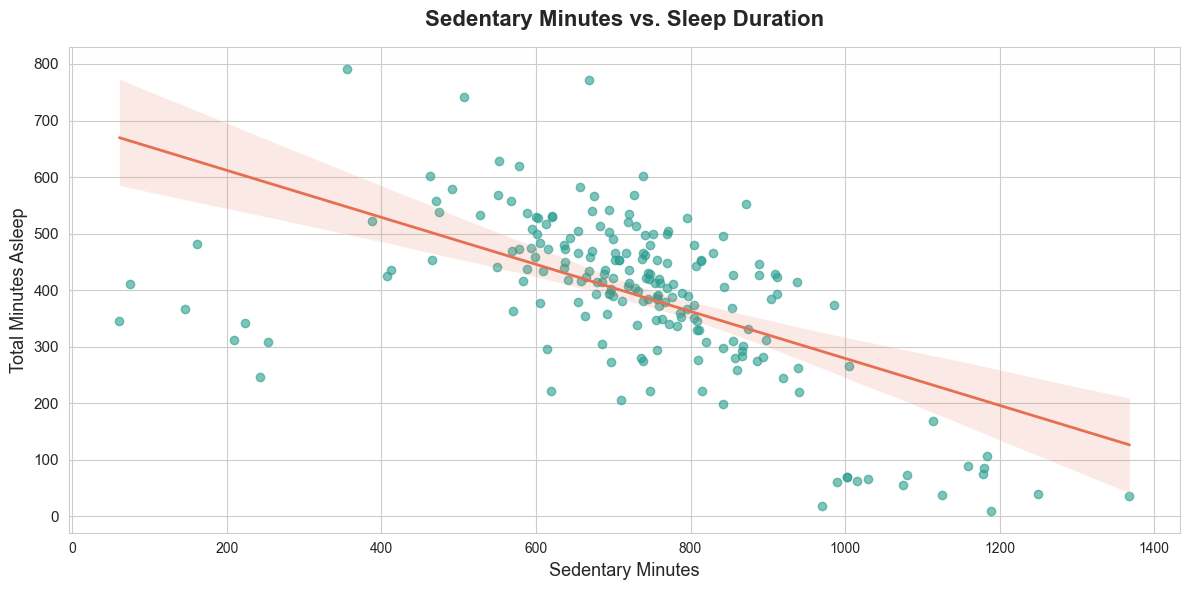

In [11]:
# Visualization: Sedentary Minutes vs. Sleep Duration (scatter + regression line)
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
sns.regplot(x=activity_sleep['SedentaryMinutes'],
            y=activity_sleep['TotalMinutesAsleep'],
            color='#2A9D8F',
            line_kws={'color': '#E76F51', 'linewidth': 2},
            scatter_kws={'alpha': 0.6})
plt.title('Sedentary Minutes vs. Sleep Duration',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sedentary Minutes', fontsize=13)
plt.ylabel('Total Minutes Asleep', fontsize=13)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

**Finding:**
- Steps vs. sleep: r = **-0.18** — too weak to be meaningful; step count alone does not predict sleep duration
- Sedentary minutes vs. sleep: r = **-0.59** — users who sit more during the day tend to sleep less

**Important caveat:** Correlation does not imply causation. This is an observed association, not a causal claim.

**Marketing implication:** The Bellabeat App's combination of activity and sleep tracking can help
users visualize the relationship between their sedentary time and sleep quality, creating a
natural hook for personalized wellness coaching.

---
### Weekday vs. Weekend Patterns

Examining whether step counts differ across days of the week.
The `DayOfWeek` column is derived from `ActivityDate` using pandas' `.dt.day_name()` method.

In [12]:
# Convert ActivityDate to datetime (loaded as object/string from CSV)
active_days['ActivityDate'] = pd.to_datetime(active_days['ActivityDate'])

# Extract day of week as a named string (Monday, Tuesday, ...)
active_days['DayOfWeek'] = active_days['ActivityDate'].dt.day_name()

# Average steps per day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
steps_by_day = active_days.groupby('DayOfWeek')['TotalSteps'].mean().reindex(day_order)
print(steps_by_day.round(1))

DayOfWeek
Monday       8067.7
Tuesday      5695.1
Wednesday    8011.4
Thursday     7825.2
Friday       7566.8
Saturday     8056.6
Sunday       6923.4
Name: TotalSteps, dtype: float64


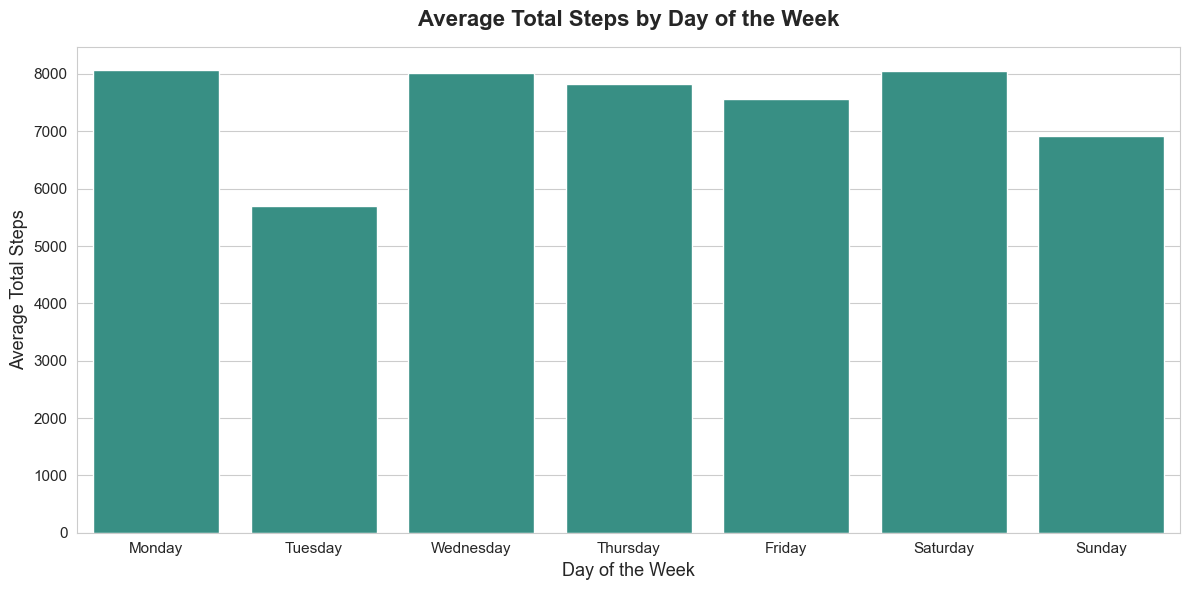

In [14]:
# Visualization: Average Steps by Day of Week
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')
sns.barplot(x='DayOfWeek',
            y='TotalSteps',
            data=active_days,
            order=day_order,
            color='#2A9D8F',
            errorbar=None)
plt.title('Average Total Steps by Day of the Week',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=13)
plt.ylabel('Average Total Steps', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

**Finding:** Activity is generally consistent across weekdays (Monday, Wednesday, Thursday, Friday
averaging 7,500–8,100 steps). Saturday maintains near-weekday activity levels while Sunday
dips noticeably (6,923 steps), suggesting a rest-day pattern.

Tuesday's notably lower average (5,695 steps) is likely a **small-sample artifact** rather than
a genuine behavioral pattern — with only ~4–5 Tuesdays in the dataset, a few unusually low
days from individual users can significantly shift the average.

**Marketing implication:** Sunday's lower activity combined with consistent device wear suggests
an opportunity for recovery-focused App content — sleep insights, weekly progress reviews,
and mindfulness prompts — rather than activity motivation on rest days.

---
## 4.3 User Segmentation

Users are segmented into three activity-level groups based on average daily steps,
using boundaries aligned with CDC and WHO physical activity guidelines:

| Segment | Avg. Daily Steps | Rationale |
|---|---|---|
| Sedentary | < 5,000 | Below minimum recommended activity threshold |
| Lightly Active | 5,000 – 7,499 | Some activity but below optimal health range |
| Active | ≥ 7,500 | Meeting or approaching recommended activity levels |

**Scope:** Only users with ≥ 12 tracked days are included (24 of 35 users).
Users below this threshold have insufficient observation windows for reliable average calculations.

In [15]:
# Step 1: Calculate average daily steps per user
user_avg_steps = (active_days
                  .groupby('Id')['TotalSteps']
                  .mean()
                  .round(1)
                  .reset_index())
user_avg_steps.columns = ['Id', 'AvgDailySteps']

# Step 2: Merge with wear_rate to access TotalDays for filtering
user_segments = pd.merge(user_avg_steps, wear_rate, on='Id')

# Step 3: Filter to users with sufficient tracked days (>= 12)
user_segments = user_segments[user_segments['TotalDays'] >= 12]
print(f'Users retained after 12-day threshold: {len(user_segments)} of 35')

Users retained after 12-day threshold: 24 of 35


In [16]:
# Step 4: Define segmentation function using CDC/WHO step benchmarks
def segment_label(avg_steps):
    """Classify a user by average daily steps into activity segments.
    
    Args:
        avg_steps (float): User's average daily step count
        
    Returns:
        str: Activity segment label ('Sedentary', 'Lightly Active', or 'Active')
    """
    if avg_steps < 5000:
        return 'Sedentary'
    elif avg_steps <= 7499:
        return 'Lightly Active'
    else:
        return 'Active'

# Verify function on boundary values
print('Function test:')
print(f'  3,000 steps → {segment_label(3000)}')
print(f'  6,500 steps → {segment_label(6500)}')
print(f'  9,000 steps → {segment_label(9000)}')

Function test:
  3,000 steps → Sedentary
  6,500 steps → Lightly Active
  9,000 steps → Active


In [17]:
# Step 5: Apply segment_label to all 24 qualifying users
# .apply() runs the function on each value in the column
user_segments['Segment'] = user_segments['AvgDailySteps'].apply(segment_label)

# Segment distribution
segment_counts = user_segments['Segment'].value_counts()
print('User segment distribution:')
print(segment_counts)
print(f'\nTotal qualifying users: {segment_counts.sum()}')

User segment distribution:
Segment
Active            11
Sedentary          9
Lightly Active     4
Name: count, dtype: int64

Total qualifying users: 24


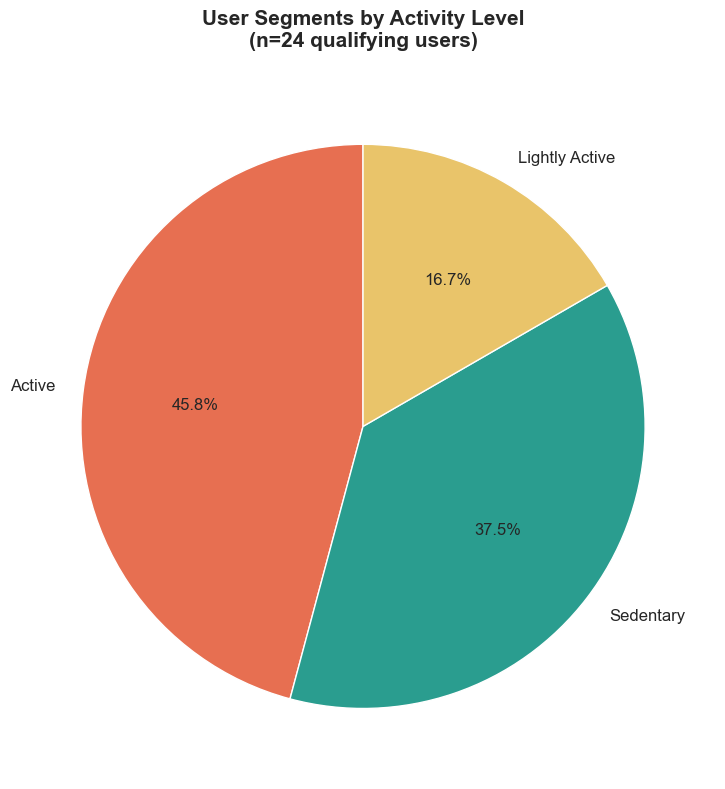

In [18]:
# Visualization: User Segments by Activity Level
plt.figure(figsize=(8, 8))
plt.pie(segment_counts,
        labels=segment_counts.index,
        colors=['#E76F51', '#2A9D8F', '#E9C46A'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12})
plt.title('User Segments by Activity Level\n(n=24 qualifying users)',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()

**Finding:**
- **Active (45.8%):** 11 users averaging ≥ 7,500 steps/day
- **Sedentary (37.5%):** 9 users averaging < 5,000 steps/day
- **Lightly Active (16.7%):** 4 users averaging 5,000–7,499 steps/day

While Active users represent the largest single group, **Sedentary + Lightly Active combined
account for 54.2%** of qualifying users — more than half are not meeting activity thresholds.
This reinforces the step-count gap identified in Section 4.1 (mean 7,405 vs. 10,000 benchmark).

**Marketing implication:** The Bellabeat App has a meaningful opportunity to serve the majority
of its user base through personalized activity coaching, goal-setting features, and motivational
content targeted at the Sedentary and Lightly Active segments.

---
## Summary of Key Findings

| # | Finding | Marketing Implication |
|---|---|---|
| 1 | 94% average wear rate among consistent users | Users are already habitual wearers — market the App's insights, not the habit |
| 2 | Mean 7,405 daily steps; 937 sedentary min/day | Significant activity gap vs. 10,000-step benchmark; sedentary users are the largest segment |
| 3 | Peak activity at 12pm and 7pm | Schedule App notifications and engagement prompts around these windows |
| 4 | Sedentary minutes negatively correlated with sleep (r = -0.59) | Cross-promote activity and sleep tracking as linked wellness behaviors |
| 5 | Sunday is the lowest-activity day | Sunday = recovery content opportunity (sleep review, mindfulness, weekly summary) |
| 6 | 54% of users are Sedentary or Lightly Active | Bellabeat membership's personalized guidance is the product for this majority segment |

---
*For full recommendations, see Section 6 (Act) of the Bellabeat Marketing Analysis Report.*